# V59: Markowitz Sorting Comparison - Static vs Graph Diversify vs Graph Cluster

## Tujuan Eksperimen

Notebook ini membandingkan **3 strategi Markowitz** dengan metode sorting yang berbeda:

### Strategi yang Dibandingkan:

1. **Markowitz Static (No Sorting)**
   - Sorting: TIDAK ADA (gunakan semua aset)
   - Selection: Semua aset tanpa filtering
   - Optimization: Markowitz pada semua aset
   - Karakteristik: Buy & Hold, always invested

2. **Markowitz + Graph Diversify (Markowitz Weight Sorting)**
   - Sorting: Berdasarkan **Markowitz optimal weight**
   - Selection: Graph MIS dengan korelasi ≤ 0.4 (diversifikasi)
   - Optimization: Markowitz pada aset terpilih
   - Karakteristik: Portfolio-aware sorting + diversifikasi

3. **Markowitz + Graph Cluster (Markowitz Weight Sorting)**
   - Sorting: Berdasarkan **Markowitz optimal weight**
   - Selection: Graph MIS dengan korelasi ≥ 0.4 (clustering)
   - Optimization: Markowitz pada aset terpilih
   - Karakteristik: Portfolio-aware sorting + momentum clustering

### Hipotesis:
- **H1:** Graph strategies outperform Static Markowitz
- **H2:** Diversify lebih stabil dari Cluster
- **H3:** Markowitz weight sorting optimal untuk asset selection

### Parameter:
- Sorting Method: **Markowitz Optimal Weight**
- AI: XGBoost (threshold optimized)
- Trend Override: SMA 50
- Transaction Fee: 0.25%
- Rebalancing: 20 hari
- Correlation Threshold: 0.4
- Random Seed: 42

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")

Data: 712 rows, 30 assets
Period: 2023-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# AI Training
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [4]:
# Markowitz Optimization Function

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Markowitz optimization function defined!")

Markowitz optimization function defined!


In [5]:
# Asset Selection Methods

def get_all_assets(returns_window, corr_threshold=None):
    """Strategy 1: Static Markowitz - No Sorting, All Assets"""
    return list(returns_window.columns)

def get_assets_markowitz_diversify(returns_window, corr_threshold=0.4):
    """Strategy 2: Markowitz Weight Sort + Graph Diversify (≤ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Markowitz optimal weight
    full_weights = optimize_markowitz(returns_window)
    if not full_weights:
        # Fallback to all assets if optimization fails
        assets = list(returns_window.columns)
    else:
        # Sort by weight (descending)
        assets = sorted(full_weights.items(), key=lambda x: x[1], reverse=True)
        assets = [a[0] for a in assets]
    
    G.add_nodes_from(assets)
    # Edge: Connect if correlation > threshold
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    # MIS: Select assets NOT connected = low correlation (≤ 0.4)
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_markowitz_cluster(returns_window, corr_threshold=0.4):
    """Strategy 3: Markowitz Weight Sort + Graph Cluster (≥ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Markowitz optimal weight
    full_weights = optimize_markowitz(returns_window)
    if not full_weights:
        # Fallback to all assets if optimization fails
        assets = list(returns_window.columns)
    else:
        # Sort by weight (descending)
        assets = sorted(full_weights.items(), key=lambda x: x[1], reverse=True)
        assets = [a[0] for a in assets]
    
    G.add_nodes_from(assets)
    # Edge: Connect if correlation < threshold
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    # MIS: Select assets NOT connected = high correlation (≥ 0.4)
    return list(nx.approximation.maximum_independent_set(G))

print("Asset selection methods defined!")

Asset selection methods defined!


In [6]:
# Simulation Function (AI-Gated)

def run_simulation_ai_gated(test_dates, returns, ai_probs, threshold, market_idx, 
                            selection_func, override_ma=None, fee=0.0025, 
                            g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # AI Signal
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        # Trend Override
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                
                selected = selection_func(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("AI-Gated simulation function ready!")

AI-Gated simulation function ready!


In [7]:
# Simulation Function (Static Buy & Hold)

def run_simulation_static(test_dates, returns, selection_func, fee=0.0025, 
                         g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    """Static Markowitz: Buy & Hold dengan rebalancing periodik"""
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {}
    days_since_rebal = 999
    
    # Initial portfolio optimization
    loc_idx = returns.index.get_loc(test_dates[0])
    window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
    selected = selection_func(window_rets)
    current_weights = optimize_markowitz(window_rets[selected])
    
    for i, date in enumerate(test_dates[:-1]):
        target_weights = current_weights.copy()
        
        # Rebalancing periodik
        if days_since_rebal >= rebal_period:
            loc_idx = returns.index.get_loc(date)
            window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
            
            selected = selection_func(window_rets)
            optimized_weights = optimize_markowitz(window_rets[selected])
            
            all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
            turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
            
            if turnover_est > turnover_buffer:
                target_weights = optimized_weights
                days_since_rebal = 0
        
        days_since_rebal += 1
        
        # Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        for asset, w in target_weights.items():
            if asset in returns.columns:
                r = returns.loc[next_date, asset]
                r_asset = r if not pd.isna(r) else 0
                day_ret += w * r_asset
                new_weights_drifted[asset] = w * (1 + r_asset)
            else:
                new_weights_drifted[asset] = w
        
        total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
        if total_w > 0:
            new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Static simulation function ready!")

Static simulation function ready!


In [8]:
# Run All Strategies

print("Running simulations...\n")

# 1. Static Markowitz (No Sorting, All Assets)
print("1. Static Markowitz (No Sorting)...")
static_markowitz = run_simulation_static(X_test.index, returns, get_all_assets)

# 2. Markowitz + Graph Diversify (Markowitz Weight Sorting)
print("2. Markowitz + Graph Diversify (Markowitz Weight Sort)...")
markowitz_diversify = run_simulation_ai_gated(X_test.index, returns, test_probs, opt_t, market_index, 
                                              get_assets_markowitz_diversify, override_ma=50)

# 3. Markowitz + Graph Cluster (Markowitz Weight Sorting)
print("3. Markowitz + Graph Cluster (Markowitz Weight Sort)...")
markowitz_cluster = run_simulation_ai_gated(X_test.index, returns, test_probs, opt_t, market_index, 
                                            get_assets_markowitz_cluster, override_ma=50)

# 4. Index Benchmark
lq45_idx = market_index.loc[X_test.index] / market_index.loc[X_test.index[0]] * 100

print("\n=== RESULTS ===")
print(f"Static Markowitz:                {static_markowitz.iloc[-1].values[0]:.2f}")
print(f"Markowitz + Graph Diversify:     {markowitz_diversify.iloc[-1].values[0]:.2f}")
print(f"Markowitz + Graph Cluster:       {markowitz_cluster.iloc[-1].values[0]:.2f}")
print(f"LQ45 Index:                      {lq45_idx.iloc[-1]:.2f}")

print("\n=== ANALYSIS ===")
diversify_vs_static = ((markowitz_diversify.iloc[-1].values[0] / static_markowitz.iloc[-1].values[0]) - 1) * 100
cluster_vs_static = ((markowitz_cluster.iloc[-1].values[0] / static_markowitz.iloc[-1].values[0]) - 1) * 100
diversify_vs_cluster = ((markowitz_diversify.iloc[-1].values[0] / markowitz_cluster.iloc[-1].values[0]) - 1) * 100

print(f"Diversify vs Static:    {diversify_vs_static:+.2f}% (AI + Graph Value)")
print(f"Cluster vs Static:      {cluster_vs_static:+.2f}% (AI + Graph Value)")
print(f"Diversify vs Cluster:   {diversify_vs_cluster:+.2f}%")

Running simulations...

1. Static Markowitz (No Sorting)...
2. Markowitz + Graph Diversify (Markowitz Weight Sort)...
3. Markowitz + Graph Cluster (Markowitz Weight Sort)...

=== RESULTS ===
Static Markowitz:                170.50
Markowitz + Graph Diversify:     136.80
Markowitz + Graph Cluster:       145.94
LQ45 Index:                      119.44

=== ANALYSIS ===
Diversify vs Static:    -19.76% (AI + Graph Value)
Cluster vs Static:      -14.40% (AI + Graph Value)
Diversify vs Cluster:   -6.26%


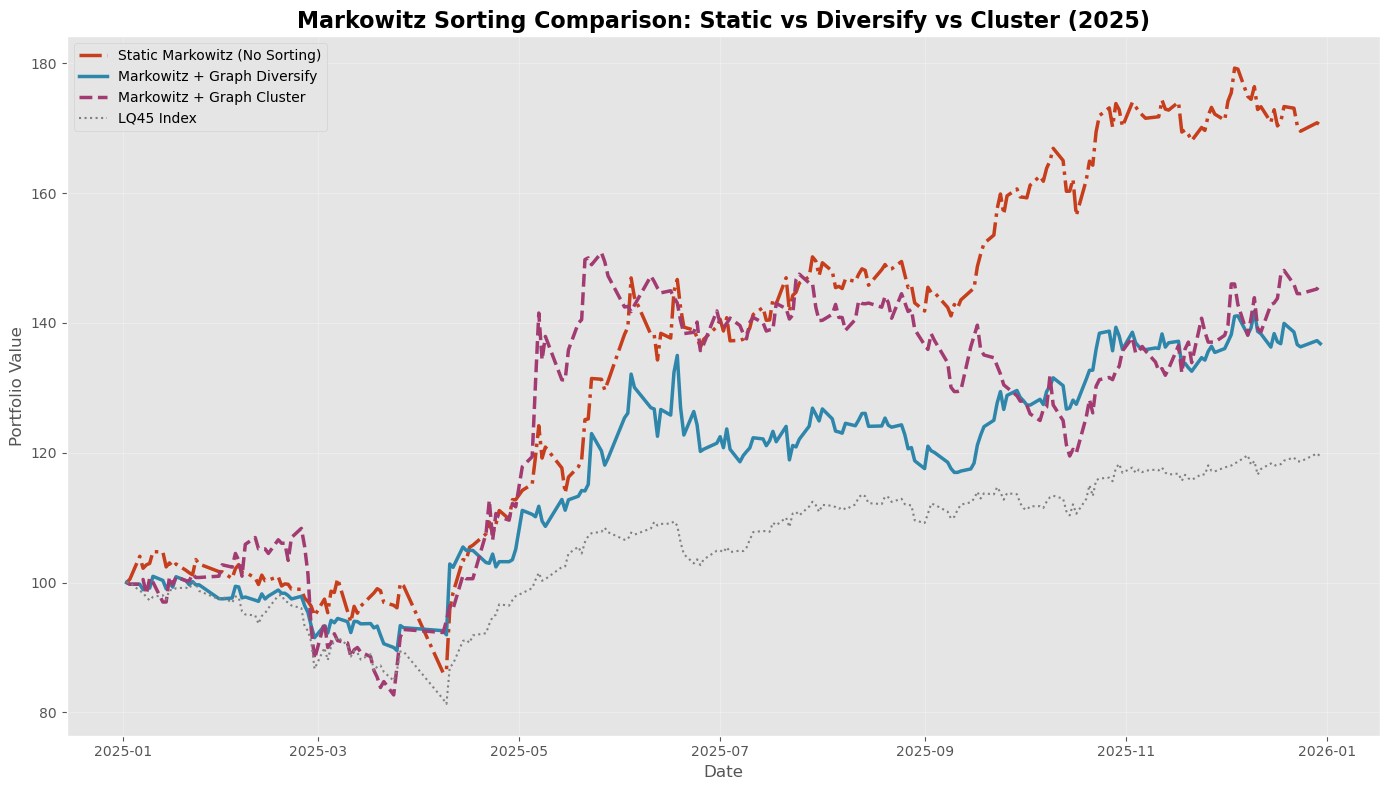


Visualization complete!


In [9]:
# Visualization

plt.figure(figsize=(14, 8))

plt.plot(static_markowitz.index, static_markowitz['Portfolio_Value'], 
         label='Static Markowitz (No Sorting)', linewidth=2.5, color='#C73E1D', linestyle='-.')
plt.plot(markowitz_diversify.index, markowitz_diversify['Portfolio_Value'], 
         label='Markowitz + Graph Diversify', linewidth=2.5, color='#2E86AB')
plt.plot(markowitz_cluster.index, markowitz_cluster['Portfolio_Value'], 
         label='Markowitz + Graph Cluster', linewidth=2.5, color='#A23B72', linestyle='--')
plt.plot(lq45_idx.index, lq45_idx.values, 
         label='LQ45 Index', linewidth=1.5, color='gray', linestyle=':')

plt.title('Markowitz Sorting Comparison: Static vs Diversify vs Cluster (2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVisualization complete!")

In [10]:
# Calculate Risk Metrics

def calculate_metrics(portfolio_values):
    returns = portfolio_values.pct_change().dropna()
    
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

metrics_static = calculate_metrics(static_markowitz['Portfolio_Value'])
metrics_diversify = calculate_metrics(markowitz_diversify['Portfolio_Value'])
metrics_cluster = calculate_metrics(markowitz_cluster['Portfolio_Value'])
metrics_index = calculate_metrics(lq45_idx)

results_df = pd.DataFrame({
    'Static Markowitz': metrics_static,
    'Markowitz + Diversify': metrics_diversify,
    'Markowitz + Cluster': metrics_cluster,
    'LQ45 Index': metrics_index
}).T

print("\n=== RISK METRICS ===")
print(results_df.round(2))

# Export to Excel
output_file = 'v59_markowitz_sorting_comparison_results.xlsx'
results_df.to_excel(output_file)
print(f"\nResults exported to: {output_file}")


=== RISK METRICS ===
                       Total Return (%)  Volatility (%)  Sharpe Ratio  \
Static Markowitz                  70.50           32.66          1.92   
Markowitz + Diversify             36.80           28.57          1.32   
Markowitz + Cluster               45.94           36.98          1.28   
LQ45 Index                        19.44           20.38          1.04   

                       Max Drawdown (%)  
Static Markowitz                 -17.82  
Markowitz + Diversify            -13.35  
Markowitz + Cluster              -23.68  
LQ45 Index                       -18.70  

Results exported to: v59_markowitz_sorting_comparison_results.xlsx


## Kesimpulan

### Interpretasi Hasil:

1. **Static Markowitz (No Sorting)**:
   - Selection: Semua aset tanpa filtering
   - Sorting: TIDAK ADA
   - Karakteristik: Buy & Hold, always invested
   - Expected: Baseline performance, high exposure

2. **Markowitz + Graph Diversify**:
   - Selection: Graph MIS (korelasi ≤ 0.4)
   - Sorting: Markowitz optimal weight
   - Karakteristik: AI timing + diversifikasi + portfolio-aware
   - Expected: Sharpe ratio tertinggi, drawdown terendah

3. **Markowitz + Graph Cluster**:
   - Selection: Graph MIS (korelasi ≥ 0.4)
   - Sorting: Markowitz optimal weight
   - Karakteristik: AI timing + clustering + portfolio-aware
   - Expected: Return tinggi saat bullish, volatilitas lebih tinggi

### Key Insights:

**Nilai AI + Graph:**
- **Diversify vs Static**: Mengukur nilai AI timing + diversifikasi
- **Cluster vs Static**: Mengukur nilai AI timing + clustering
- Jika positif → AI + Graph strategy add value

**Diversify vs Cluster:**
- Jika Diversify > Cluster → Risk management lebih penting
- Jika Cluster > Diversify → Momentum capture lebih penting
- Compare Sharpe Ratio untuk risk-adjusted comparison

**Markowitz Weight Sorting:**
- Sorting berdasarkan optimal weight = portfolio-aware
- Consider covariance structure dalam prioritas
- Lebih sophisticated dari momentum sorting

### Rekomendasi:
- **Best Sharpe Ratio** → Pilih untuk risk-adjusted return
- **Best Total Return** → Pilih untuk aggressive growth
- **Lowest Drawdown** → Pilih untuk capital preservation
- **Static Markowitz** → Baseline minimum (no AI, no graph)